In [2]:
import kagglehub as kh
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as td
from torch import nn
import torchcurves as tc
from typing import Sequence
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

In [3]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [4]:
file_path = "housing.csv"
df = kh.dataset_load(kh.KaggleDatasetAdapter.PANDAS, "camnugent/california-housing-prices", file_path)

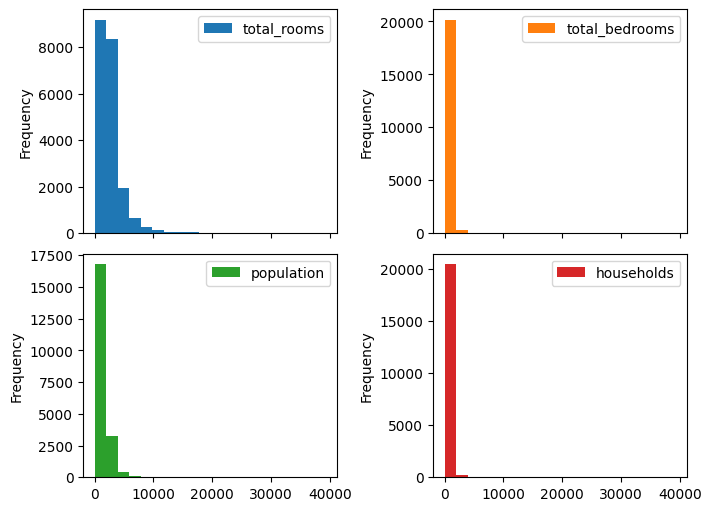

In [5]:
# columns that we know have a very skewed distribution
skewed_columns = ['total_rooms', 'total_bedrooms', 'population', 'households']
df[skewed_columns].plot.hist(bins=20, subplots=True, layout=(2, 2), figsize=(7, 5))
plt.gcf().set_layout_engine('constrained')

In [6]:
df.loc[:, skewed_columns] = df[skewed_columns].apply(np.log)

In [7]:
spectral_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
spatial_cols = ['longitude', 'latitude', 'housing_median_age']
numerical_cols = spatial_cols + spectral_cols
cat_cols = ['ocean_proximity']
num_cat_features = sum(1 + df[col].nunique() for col in cat_cols)
label_col = 'median_house_value'

In [8]:
train_df = df.sample(frac=0.8, random_state=2025)
test_df = df.drop(train_df.index)

# Preprocess data

In [9]:
X_train, y_train = train_df.drop(label_col, axis=1), train_df[[label_col]]
X_test, y_test = test_df.drop(label_col, axis=1), test_df[[label_col]]

In [10]:
feat_preprocessor = make_column_transformer(
    (OrdinalEncoder(), cat_cols),                                                     # categorical: ordinal encode
    (make_pipeline(SimpleImputer(), StandardScaler()), numerical_cols), # numerical: impute then scale
    verbose_feature_names_out=False
).set_output(transform='pandas')
label_preprocessor = StandardScaler()

In [11]:
X_train_pp = feat_preprocessor.fit_transform(X_train)
X_test_pp = feat_preprocessor.transform(X_test)

y_train_pp = label_preprocessor.fit_transform(y_train)
y_test_pp = label_preprocessor.transform(y_test)

In [13]:
X_train_pp[cat_cols] = X_train_pp[cat_cols].astype(np.int32)
X_train_pp[numerical_cols] = X_train_pp[numerical_cols].astype(np.float32)
X_test_pp[cat_cols] = X_test_pp[cat_cols].astype(np.int32)
X_test_pp[numerical_cols] = X_test_pp[numerical_cols].astype(np.float32)

col_sets = [spectral_cols, spatial_cols, cat_cols]
X_train_tensors = tuple(torch.as_tensor(X_train_pp[cols].values) for cols in col_sets)
X_test_tensors = tuple(torch.as_tensor(X_test_pp[cols].values) for cols in col_sets)

# Tran and evaluate GBDT as a baseline

In [14]:
baseline_model = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(), cat_cols),
        remainder='passthrough'
    ),
    HistGradientBoostingRegressor(loss='squared_error')
)
baseline_model.fit(X_train, y_train.values.ravel())
pred = baseline_model.predict(X_test)
baseline_rmse = root_mean_squared_error(y_test, pred)
print(f'Baseline RMSE = {baseline_rmse}')

Baseline RMSE = 47009.00606732456


In [15]:
baseline_model = make_pipeline(
    feat_preprocessor,
    LinearRegression()
)
baseline_model.fit(X_train, y_train.values.ravel())
pred = baseline_model.predict(X_test)
baseline_rmse = root_mean_squared_error(y_test, pred)
print(f'Baseline RMSE = {baseline_rmse}')

Baseline RMSE = 65867.86914385633


# Train and evaluate models

In [13]:
class EmbeddingLayer(nn.Module):
    def __init__(self, n_spectral: int, n_spatial: int, n_cat: Sequence[int], emb_dim: int, n_coef: int = 10,
                 dropout_p=0.1):
        super().__init__()

        # offset for the categorical feature of each column
        offsets = [sum(n_cat[:i]) for i in range(len(n_cat))]
        self.register_buffer("offsets", torch.tensor(offsets))

        # embeddings for each type of feature
        self.spectral_emb = tc.LegendreCurve(n_spectral, emb_dim, degree=n_coef - 1, normalize_fn='rational')
        self.spatial_emb = tc.BSplineEmbeddings(n_spatial, emb_dim, knots_config=n_coef, normalize_fn='rational')
        self.cat_emb = nn.Embedding(sum(n_cat), emb_dim)

        # post-processing for the embeddings, before feeding them into the transformer
        self.postprocess = nn.Sequential(nn.LayerNorm(emb_dim), nn.Dropout(dropout_p))

    def forward(self, x_spectral, x_spatial, x_cat):
        spectral_emb = self.spectral_emb(x_spectral)
        spatial_emb = self.spatial_emb(x_spatial)
        cat_emb = self.cat_emb(x_cat + self.offsets.to(x_cat.dtype).unsqueeze(0))
        emb = torch.concatenate((spectral_emb, spatial_emb, cat_emb), dim=-2)
        return self.postprocess(emb)

    @staticmethod
    def get_offsets(n_cat: Sequence[int]):
        sum = 0
        yield sum
        for n in n_cat:
            sum += n

In [14]:
class TransformerModel(nn.Module):
    def __init__(self,
                 n_spectral: int, n_spatial: int, n_cat: Sequence[int], emb_dim: int, n_coef: int = 10,
                 num_heads: int = 4, num_layers: int = 4, dim_feedforward: int = 64):
        super().__init__()
        self.embeddings = EmbeddingLayer(n_spectral, n_spatial, n_cat, emb_dim, n_coef)
        self.transformer = nn.TransformerEncoder(
            encoder_layer=nn.TransformerEncoderLayer(
                emb_dim, num_heads, batch_first=True, activation='gelu', dim_feedforward=dim_feedforward
            ),
            num_layers=num_layers
        )
        self.fc = nn.Linear(emb_dim, 1)

    def forward(self, tensors: Sequence[torch.Tensor]):
        emb = self.embeddings(*tensors)
        encoded = self.transformer(emb)
        pooled = torch.mean(encoded, axis=-2)
        return self.fc(pooled)

In [15]:
# architecture
num_heads = 4
num_layers = 2
emb_dim = 32

# data
num_epochs = 500
print_every = 25
batch_size = 32

# optimizer
lr = 5e-5
weight_decay = 1e-5

# sizes
num_features = X_train_pp.shape[1]
train_set_size = len(X_train_pp)
test_set_size = len(X_test_pp)

In [16]:
train_ds = td.TensorDataset(*X_train_tensors, torch.as_tensor(y_train_pp).float())
eval_ds = td.TensorDataset(*X_test_tensors, torch.as_tensor(y_test_pp).float())

In [17]:
def train_epoch(model, optim, criterion, train_dl):
    tr_loss = 0.
    for *Xb, yb in train_dl:
        pred = model(xb.to(device) for xb in Xb)
        loss = criterion(yb, pred)

        optim.zero_grad()
        loss.backward()
        optim.step()

        tr_loss += loss * torch.numel(yb)
    return tr_loss.item() / train_set_size


@torch.no_grad
def eval_epoch(model, eval_criterion, eval_dl):
    eval_total_error = 0.
    for *Xb, yb in eval_dl:
        # predict
        pred = model(xb.to(device) for xb in Xb)

        # compute label and prediction in terms of the original, unscaled labels
        label_orig = label_preprocessor.inverse_transform(yb.view(-1, 1))
        pred_orig = label_preprocessor.inverse_transform(pred.cpu().view(-1, 1))

        # compute loss on the original labels
        loss = eval_criterion(
            torch.as_tensor(label_orig, device=device, dtype=torch.float32),
            torch.as_tensor(pred_orig, device=device, dtype=torch.float32)
        )
        eval_total_error += loss * torch.numel(yb)
    return eval_total_error.item() / test_set_size

In [18]:
def train_eval_model(name, model: nn.Module, batch_size: int, print_progress=True, **optim_kwargs):
    model = model.to(device)
    optim = torch.optim.AdamW(model.parameters(), **optim_kwargs)
    criterion = nn.MSELoss()
    train_dl = td.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    eval_dl = td.DataLoader(eval_ds, batch_size=128)

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = train_epoch(model, optim, criterion, train_dl)

        model.eval()
        eval_loss = eval_epoch(model, criterion, eval_dl)
        eval_rmse = math.sqrt(eval_loss)

        if print_progress and (epoch % print_every == 0 or epoch == num_epochs):
            print(f'[{name}] Epoch {epoch}, tr loss = {train_loss:.4f}, eval RMSE = {eval_rmse:.2f}')

    return model

In [20]:
highdeg_legendre_model = train_eval_model(
    "Transformer-10",
    TransformerModel(
        len(spectral_cols), len(spatial_cols), [num_cat_features],
        emb_dim=emb_dim, num_heads=num_heads, num_layers=num_layers, n_coef=10,
    ),
    lr=lr, weight_decay=weight_decay, batch_size=batch_size
)

[Transformer-10] Epoch 25, tr loss = 0.2512, eval RMSE = 54491.00
[Transformer-10] Epoch 50, tr loss = 0.2208, eval RMSE = 52716.54
[Transformer-10] Epoch 75, tr loss = 0.2068, eval RMSE = 51265.74
[Transformer-10] Epoch 100, tr loss = 0.1946, eval RMSE = 49578.03
[Transformer-10] Epoch 125, tr loss = 0.1861, eval RMSE = 48883.57
[Transformer-10] Epoch 150, tr loss = 0.1809, eval RMSE = 48403.21
[Transformer-10] Epoch 175, tr loss = 0.1755, eval RMSE = 48130.87
[Transformer-10] Epoch 200, tr loss = 0.1737, eval RMSE = 48181.80
[Transformer-10] Epoch 225, tr loss = 0.1692, eval RMSE = 48177.43
[Transformer-10] Epoch 250, tr loss = 0.1634, eval RMSE = 47943.78
[Transformer-10] Epoch 275, tr loss = 0.1628, eval RMSE = 48035.55
[Transformer-10] Epoch 300, tr loss = 0.1627, eval RMSE = 47737.15
[Transformer-10] Epoch 325, tr loss = 0.1603, eval RMSE = 47808.32
[Transformer-10] Epoch 350, tr loss = 0.1542, eval RMSE = 47651.46
[Transformer-10] Epoch 375, tr loss = 0.1527, eval RMSE = 47826.5